# Chapter 174 — PCA Intuition

> **Prerequisites:** ch173 (SVD), ch172 (Diagonalization), ch167 (Scaling via Matrices), ch155 (Matrix Transpose)
> **You will learn:**
> - What PCA is trying to find and why
> - The connection between PCA and SVD/eigendecomposition
> - How to interpret principal components geometrically
> - When PCA helps and when it misleads
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Principal Component Analysis (PCA) answers a single question: **what directions in the data have the most variance?**

Given a dataset X (n samples × p features), PCA finds a sequence of orthogonal directions w₁, w₂, ... such that:
- w₁ captures the maximum variance in the data
- w₂ captures the maximum remaining variance, subject to being orthogonal to w₁
- ... and so on

These directions are the **principal components**. Projecting the data onto the first k principal components gives the best k-dimensional linear approximation to the data.

**Common misconception:** PCA does not find "the most interesting" directions — it finds the highest-variance directions. High variance is not the same as high signal. Noise can dominate low-signal dimensions.

## 2. Intuition & Mental Models

**Geometric:** Imagine a cloud of points in 3D that lies mostly in a thin pancake shape. PCA finds the plane of the pancake. The first two principal components span that plane. The third principal component is perpendicular to it (the "thin" direction).

**Ellipse of data:** The covariance matrix of the data defines an ellipse (in 2D) or ellipsoid (in higher D). The principal axes of this ellipse are the eigenvectors of the covariance matrix. The lengths of those axes are proportional to the square roots of the eigenvalues — which are the singular values from ch173.

**Computational:** PCA is either:
1. Eigendecompose the covariance matrix C = XᵀX/(n-1)
2. SVD of the centered data matrix X directly: X = UΣVᵀ → principal components = columns of V

Option 2 is numerically superior. Most implementations use SVD.

Recall from ch173: U (left singular vectors) are in data space; V (right singular vectors) are in feature space. The principal components are columns of V.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_21072\3951117559.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21072\3951117559.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


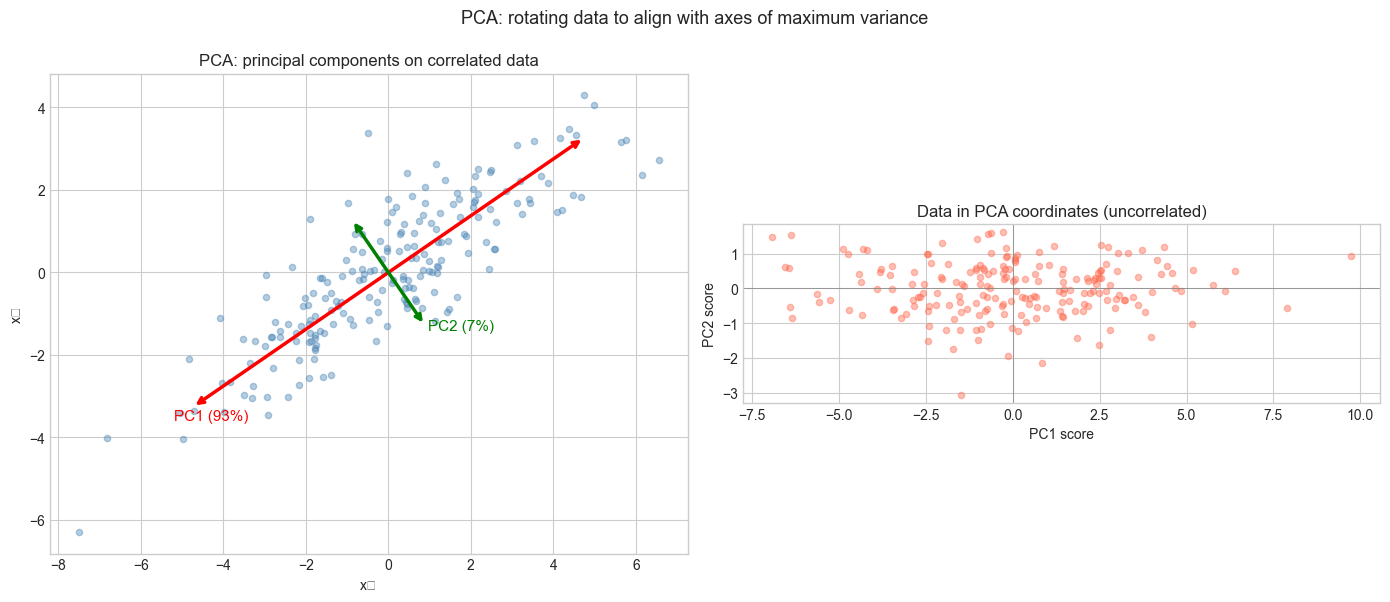

Variance explained: PC1=93.3%, PC2=6.7%


In [1]:
# --- Visualization: PCA finds the axes of the data ellipse ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

# Generate correlated 2D data
n = 200
theta_data = np.radians(35)
R = np.array([[np.cos(theta_data), -np.sin(theta_data)],
              [np.sin(theta_data),  np.cos(theta_data)]])
raw = np.random.randn(n, 2) * np.array([3.0, 0.8])
X = raw @ R.T  # rotate to create correlation

# Center
X_centered = X - X.mean(axis=0)

# PCA via SVD
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
components = Vt  # rows are principal components
explained_var = s**2 / (n - 1)
total_var = explained_var.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data + PCA directions
ax = axes[0]
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.4, s=20, color='steelblue')
for i, (comp, var) in enumerate(zip(components, explained_var)):
    scale = np.sqrt(var) * 2
    ax.annotate('', xy=comp*scale, xytext=-comp*scale,
                arrowprops=dict(arrowstyle='<->', color=['red','green'][i], lw=2.5))
    ax.text(comp[0]*scale*1.1, comp[1]*scale*1.1,
            f'PC{i+1} ({var/total_var:.0%})', color=['red','green'][i], fontsize=11)
ax.set_aspect('equal')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('PCA: principal components on correlated data')

# Projected data
X_proj = X_centered @ Vt.T  # project onto PCA coordinates
ax2 = axes[1]
ax2.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.4, s=20, color='tomato')
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
ax2.set_aspect('equal')
ax2.set_xlabel('PC1 score'); ax2.set_ylabel('PC2 score')
ax2.set_title('Data in PCA coordinates (uncorrelated)')

plt.suptitle('PCA: rotating data to align with axes of maximum variance', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Variance explained: PC1={explained_var[0]/total_var:.1%}, PC2={explained_var[1]/total_var:.1%}")

## 4. Mathematical Formulation

**Setup:** Data matrix X (n × p), centered: X_c = X - mean(X, axis=0)

**Covariance matrix:** C = X_cᵀ X_c / (n-1)  — a p×p symmetric positive semidefinite matrix.

**Eigendecomposition of C:** C = V Λ Vᵀ (spectral theorem — symmetric matrix)
- Columns of V: principal component directions
- Diagonal entries of Λ: variances along each principal component

**Via SVD:** X_c = U Σ Vᵀ

    C = X_cᵀX_c/(n-1) = V Σᵀ Uᵀ U Σ Vᵀ/(n-1) = V (Σ²/(n-1)) Vᵀ

So V is identical in both formulations. Eigenvalues λᵢ = σᵢ²/(n-1).

**Proportion of variance explained:**

    PVE(k) = Σᵢ₌₁ᵏ λᵢ / Σᵢ λᵢ  =  Σᵢ₌₁ᵏ σᵢ² / Σᵢ σᵢ²

**Reconstruction:**

    X̂ₖ = X_c Vₖ Vₖᵀ + mean    (project onto k components, add back mean)

## 5. Python Implementation

In [2]:
# --- Implementation: PCA from scratch ---
import numpy as np

class PCA:
    """
    Principal Component Analysis via SVD.

    Attributes:
        components_: (n_components, n_features) — principal component directions
        explained_variance_: (n_components,) — variance along each PC
        explained_variance_ratio_: (n_components,) — fraction of total variance
        mean_: (n_features,) — feature means
    """

    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        """
        Compute principal components from data X.

        Args:
            X: (n_samples, n_features) data matrix
        """
        n, p = X.shape
        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_

        # SVD of centered data
        _, s, Vt = np.linalg.svd(X_c, full_matrices=False)

        k = self.n_components or p
        self.components_ = Vt[:k]
        self.explained_variance_ = s[:k]**2 / (n - 1)
        total_var = np.sum(s**2) / (n - 1)
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        return self

    def transform(self, X):
        """Project data onto principal components."""
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, Z):
        """Reconstruct data from PCA coordinates."""
        return Z @ self.components_ + self.mean_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# Test on correlated data
np.random.seed(7)
n = 300
X = np.random.randn(n, 4) @ np.array([[1, 0.8, 0.5, 0.1],
                                        [0, 0.6, 0.3, 0.9],
                                        [0, 0,   0.7, 0.2],
                                        [0, 0,   0,   0.4]])

pca = PCA(n_components=2)
Z = pca.fit_transform(X)
X_rec = pca.inverse_transform(Z)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")
print(f"Reconstruction error: {np.mean((X - X_rec)**2):.6f}")
print(f"Original shape: {X.shape}, Compressed shape: {Z.shape}")

Explained variance ratio: [0.6803 0.2216]
Total variance captured: 90.2%
Reconstruction error: 0.091006
Original shape: (300, 4), Compressed shape: (300, 2)


## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_21072\1013855981.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21072\1013855981.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


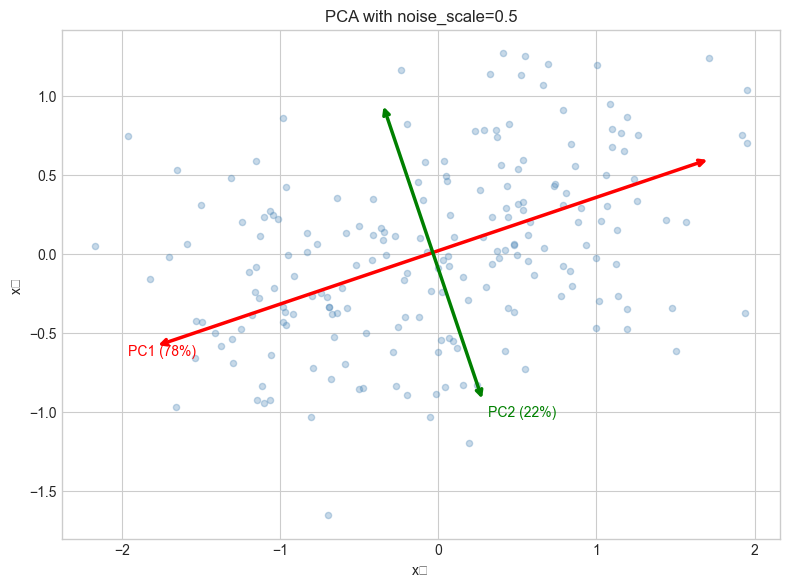

In [3]:
# --- Experiment 1: PCA on structured noise vs signal ---
# Hypothesis: When signal-to-noise ratio is low, PCA may capture noise first
# Try changing: NOISE_SCALE

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

NOISE_SCALE = 0.5  # try: 0.1, 0.5, 1.0, 3.0
np.random.seed(0)

n = 200
# Signal: correlated along first axis
t = np.linspace(0, 2*np.pi, n)
signal = np.stack([np.sin(t), 0.3 * np.sin(t)], axis=1)
noise = NOISE_SCALE * np.random.randn(n, 2)
X = signal + noise

pca = PCA(n_components=2)
pca.fit(X)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=20, color='steelblue', label='Data')
for i, comp in enumerate(pca.components_):
    scale = np.sqrt(pca.explained_variance_[i]) * 2
    ax.annotate('', xy=pca.mean_ + comp*scale, xytext=pca.mean_ - comp*scale,
                arrowprops=dict(arrowstyle='<->', color=['red','green'][i], lw=2.5))
    ax.text(*(pca.mean_ + comp*scale*1.1),
            f'PC{i+1} ({pca.explained_variance_ratio_[i]:.0%})',
            color=['red','green'][i], fontsize=10)
ax.set_aspect('equal')
ax.set_title(f'PCA with noise_scale={NOISE_SCALE}')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
plt.tight_layout()
plt.show()

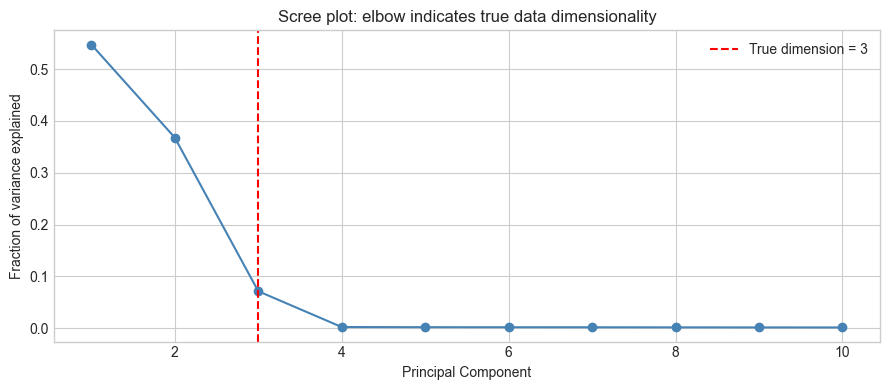

In [4]:
# --- Experiment 2: Scree plot for choosing number of components ---
# Hypothesis: The "elbow" in the scree plot indicates the true data dimensionality
# Try changing: TRUE_DIM

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

TRUE_DIM = 3   # try: 1, 2, 3, 5
P_TOTAL = 10   # total features
np.random.seed(42)

# Data lives in TRUE_DIM dimensions, embedded in P_TOTAL-dim space
Z_true = np.random.randn(300, TRUE_DIM)
W = np.random.randn(TRUE_DIM, P_TOTAL)
X = Z_true @ W + 0.2 * np.random.randn(300, P_TOTAL)

pca = PCA()
pca.fit(X)

plt.figure(figsize=(9, 4))
plt.plot(range(1, P_TOTAL+1), pca.explained_variance_ratio_, 'o-', color='steelblue')
plt.axvline(TRUE_DIM, color='red', ls='--', label=f'True dimension = {TRUE_DIM}')
plt.xlabel('Principal Component')
plt.ylabel('Fraction of variance explained')
plt.title('Scree plot: elbow indicates true data dimensionality')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** If a dataset has 0 correlation between features, what do you expect the principal components to be? Verify with a 2D dataset where x₁ and x₂ are independent standard normals.

**Easy 2.** What is the first principal component of a 1D dataset? Write the trivial answer, then verify it with the `PCA` class.

**Medium 1.** Apply PCA to the Iris dataset (generate it using `np.random.randn` with known structure: 3 clusters, 4 features). Project to 2D and color-code by cluster. Does PCA preserve cluster separation?

**Medium 2.** PCA is sensitive to feature scale. Take a dataset where one feature has values in [0, 1000] and another in [0, 1]. Run PCA before and after standardizing (z-score normalization). Show that the principal components change dramatically.

**Hard.** PCA is equivalent to solving the optimization: max_{||w||=1} wᵀCw where C is the covariance matrix. Show that the solution is the leading eigenvector of C. Then extend: what is the second principal component (orthogonal to first, maximum remaining variance)?

## 8. Mini Project: Visualizing High-Dimensional Data with PCA

Explained variance ratio: [0.79  0.137 0.069]
Top 3 PCs capture: 99.6% of variance


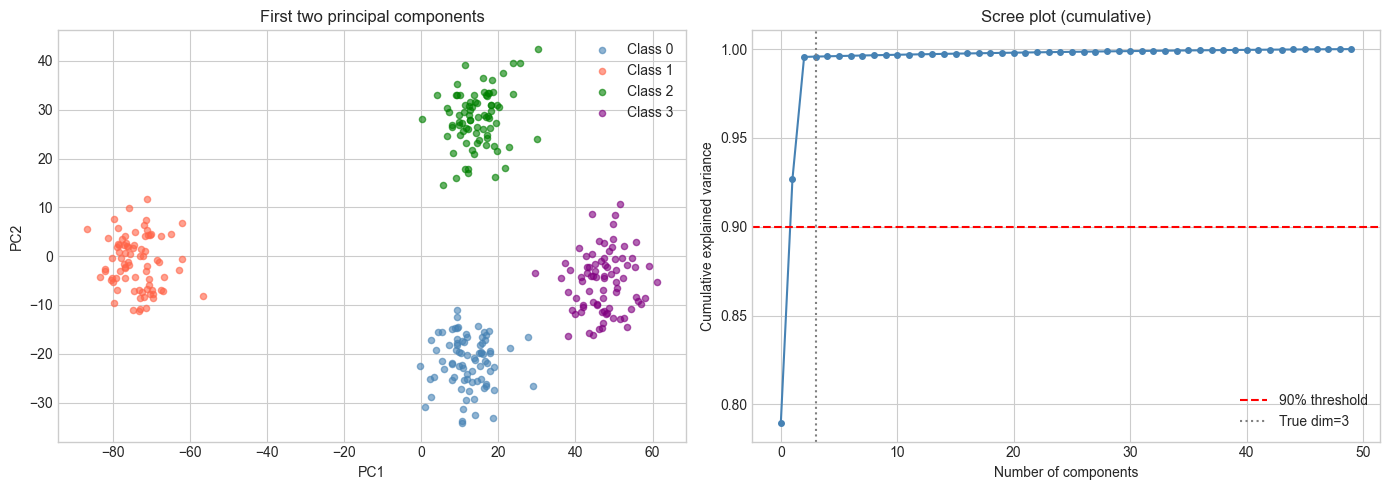

In [5]:
# --- Mini Project: Explore PCA on structured synthetic high-dim data ---
# Problem: A dataset has 50 features but only 3 meaningful dimensions.
#          Use PCA to recover the latent structure and visualize it.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(0)
N_CLASSES = 4
N_PER_CLASS = 80
N_FEATURES = 50
LATENT_DIM = 3

# Generate: each class is a Gaussian cloud in latent space
class_centers = np.random.randn(N_CLASSES, LATENT_DIM) * 5
W = np.random.randn(LATENT_DIM, N_FEATURES)  # projection to high-dim

X_list, y_list = [], []
for c in range(N_CLASSES):
    Z = class_centers[c] + np.random.randn(N_PER_CLASS, LATENT_DIM) * 0.8
    X_list.append(Z @ W + 0.5 * np.random.randn(N_PER_CLASS, N_FEATURES))
    y_list.append(np.full(N_PER_CLASS, c))

X = np.vstack(X_list)
y = np.concatenate(y_list)

# Apply PCA
pca = PCA(n_components=3)
Z_pca = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Top 3 PCs capture: {pca.explained_variance_ratio_.sum():.1%} of variance")

fig = plt.figure(figsize=(14, 5))

# 2D projection
ax1 = fig.add_subplot(121)
colors = ['steelblue', 'tomato', 'green', 'purple']
for c in range(N_CLASSES):
    mask = y == c
    ax1.scatter(Z_pca[mask, 0], Z_pca[mask, 1], s=20, alpha=0.6,
               color=colors[c], label=f'Class {c}')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('First two principal components')
ax1.legend()

# Scree plot
pca_full = PCA()
pca_full.fit(X)
ax2 = fig.add_subplot(122)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(cum_var, 'o-', color='steelblue', markersize=4)
ax2.axhline(0.9, color='red', ls='--', label='90% threshold')
ax2.axvline(LATENT_DIM, color='gray', ls=':', label=f'True dim={LATENT_DIM}')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative explained variance')
ax2.set_title('Scree plot (cumulative)')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- PCA finds the directions of maximum variance in a dataset via eigendecomposition of the covariance matrix or SVD of the centered data matrix.
- Principal components are orthogonal; projecting onto them removes correlations between features.
- The proportion of variance explained (scree plot) guides the choice of number of components.
- PCA is a linear method — it cannot capture nonlinear structure (manifolds, clusters arranged nonlinearly).
- Feature scaling before PCA is critical: features with large ranges will dominate without it.

**Backward:** PCA is diagonalization (ch172) of the covariance matrix, and its computation uses SVD (ch173) of the centered data.

**Forward:**
- ch175 (Dimensionality Reduction): generalizing PCA — when to use it, limitations, alternatives
- ch181 (Project: PCA Visualization): interactive PCA explorer on real-ish data
- ch187 (Face Recognition PCA): eigenfaces — PCA on image data for recognition
- ch282 (Dimensionality Reduction): t-SNE, UMAP as nonlinear alternatives

**Going deeper:** Kernel PCA extends PCA to nonlinear structure by implicitly mapping data to a high-dimensional space (kernel trick). Probabilistic PCA (Tipping & Bishop, 1999) gives PCA a generative model interpretation.